In [29]:
import pandas as pd
import geopandas

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

from pathlib import Path
import glob

In [30]:
PATH = Path('../KNPAnthrax/bin/Debug/net6.0/osx-arm64')

In [31]:
kudu_df = pd.read_csv(PATH / 'Kudu.csv', sep=';', parse_dates=['DateTime'])

In [32]:
unique_kudu_agents = list(kudu_df['ID'].unique())

In [37]:
print(f"There are {len(unique_kudu_agents)} agents/herds")

There are 50 agents/herds


In [34]:
kudu_stats = []
for agent_id in unique_kudu_agents:
    # filter down CSV to only entries specific to ONE agent/herd!
    agent_df = kudu_df[kudu_df['ID'] == agent_id]
    
    kudu_stats.append({
        'id': agent_id,
        'infected_total_counter': agent_df['InfectedTotalCounter'].max() # max value mus be from the end of simulation / last tick, since we never decrease it
    })
stats_df = pd.DataFrame(kudu_stats)

In [35]:
print(f"Total infections for Kudus: {stats_df['infected_total_counter'].sum()}")

Total infections for Kudus: 453


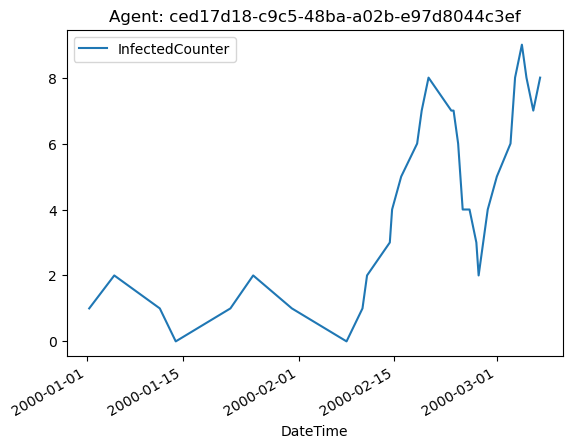

In [36]:
def create_plot(agent_id, df):
    dfx = df[df['ID'] == agent_id]
    dfx.plot(x='DateTime', y='InfectedCounter') # InfectedCounter or InfectedTotalCounter
    plt.title(f"Agent: {agent_id}")
    
create_plot(unique_kudu_agents[0], kudu_df)